# DNAscape tests (dev)

## Imports and configuration

In [ ]:
# Import DNAscape
from dnascape import *

## Examples

### Quickstart

In [2]:
timedata = loadcsv('example', example='replication_timing_hESC', chr_number=1)

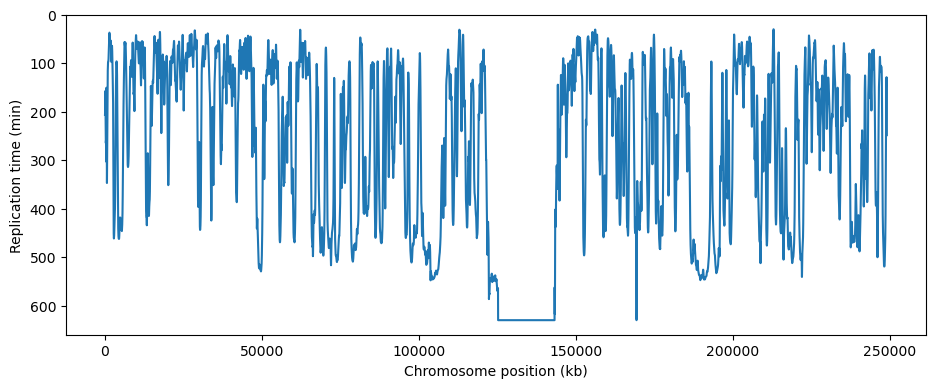

In [3]:
plotf(timedata, xtitle='Chromosome position (kb)', ytitle='Replication time (min)', invyQ=True) #saveQ=True, sname='quick1', ext='png'

In [4]:
frates = rfit('replication_timing', 'firing_rate', source=timedata, maxiter=2)

[2/2]  Elapsed: 00:00:29  ETA: 00:00:00  MSE: 1.5082e+03

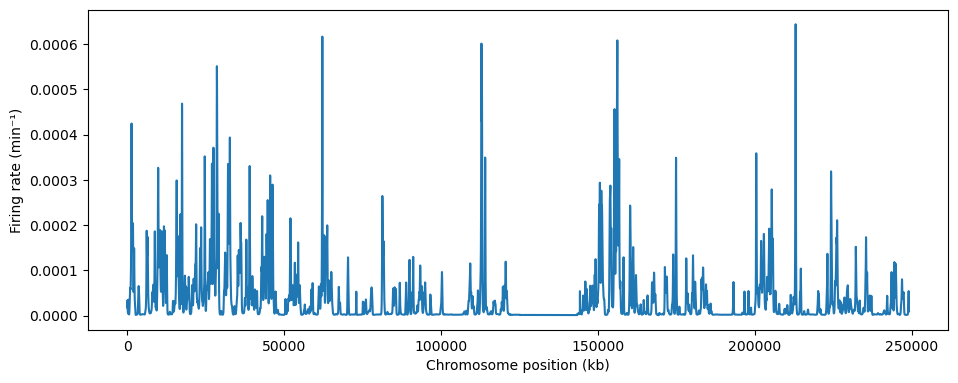

In [5]:
plotf(frates, xtitle='Chromosome position (kb)', ytitle='Firing rate (min⁻¹)')

In [ ]:
timepred = rfit('firing_rate', 'replication_timing', source=frates)

In [ ]:
plotf(timedata[10000:40000], timepred[10000:40000],
      labels=['Timing data', 'Timing prediction'], xtitle='Chromosome position (kb)', ytitle='Time (min)', invyQ=True)

In [ ]:
simres = rsim(frates, fork_speed=1.4, time_statsQ=True, sim_number=1000)

In [6]:
simres = rsim(frates, fork_speed=1.4, time_statsQ=True, time_stats_densQ=True, sim_number=100)

[61/61]  Elapsed: 00:00:07  ETA: 00:00:0000

In [7]:
timesim = simres['replication_timing']
iod = simres['inter_origin_distances']
frep = simres['replicated_fraction']
forka = simres['active_forks']
nroris = simres['num_oris']
effic = simres['efficiency']

In [69]:
frep = simres['replicated_fraction']
ievents = simres['initiation_events']
cevents = simres['coalescence_events']
rforks = simres['right_moving_fork_density']
lforks = simres['left_moving_fork_density']

list_dens = [list[:,10000:20000] for list in [frep, ievents, cevents, rforks, lforks]]

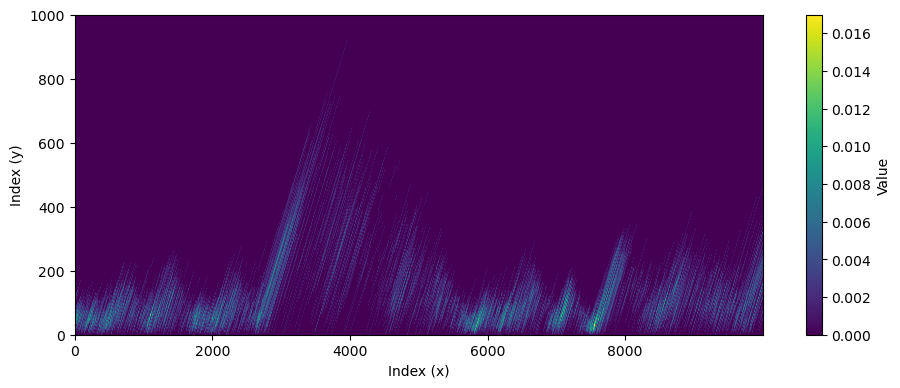

(<Figure size 1000x400 with 2 Axes>,
 <Axes: xlabel='Index (x)', ylabel='Index (y)'>,
 <matplotlib.colorbar.Colorbar at 0x1daead6fc50>)

In [78]:
plothm(list_dens[3], ylims=(0,1000), gaussian_sigma=2)

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom, gaussian_filter


def plothm(
    field,
    resolution_hm=None,
    smooth_type="bicubic",
    bscale=None,
    cmap="viridis",
    x_ticks=None,
    t_ticks=None,
    xtitle="Index (x)",
    ytitle="Index (y)",
    ctitle="Value",
    figsize=(10, 4),
    xlims=(None, None),
    ylims=(None, None),
    invyQ=False,
    x_show=True,
    y_show=True,
    region_high=None,
    rname="Region",
    saveQ=False,
    sname="test",
    ext="pdf",
    layout_rect=(0.12, 0.15, 0.98, 0.95),
    fig=None,
    ax=None,
    showQ=True,
    # --- new (optional) ---
    gaussian_sigma=None,       # e.g. 1.0–2.0 for "denser" look; None/0 disables
    gaussian_mode="nearest",   # how boundaries are handled
):
    """
    Plot a heatmap with optional Gaussian smoothing (density-like) and optional resampling.

    Notes
    - gaussian_sigma applies a Gaussian filter to the data before any resampling.
    - interpolation in imshow is only a rendering choice; resampling is handled via zoom.
    - colourbar limits (when bscale is None) are computed from the displayed data range
      within xlims/ylims, mapped onto the plotted grid.
    """

    # 1. Prepare Data
    F = np.asarray(field, dtype=float)
    if F.ndim != 2:
        raise ValueError(f"`field` must be 2D, got shape {F.shape}.")
    orig_nt, orig_nx = F.shape

    # 2. Optional Gaussian smoothing (acts like density spreading)
    if gaussian_sigma is not None and float(gaussian_sigma) > 0:
        F_base = gaussian_filter(F, sigma=float(gaussian_sigma), mode=gaussian_mode)
    else:
        F_base = F

    # 3. Handle Resolution Tweak (Resampling)
    if resolution_hm is not None:
        # allow int or (nt, nx)
        if np.isscalar(resolution_hm):
            target_nt = int(resolution_hm)
            target_nx = int(resolution_hm)
        else:
            if len(resolution_hm) != 2:
                raise ValueError("`resolution_hm` must be None, an int, or a (nt, nx) tuple.")
            target_nt, target_nx = map(int, resolution_hm)

        if target_nt <= 0 or target_nx <= 0:
            raise ValueError("`resolution_hm` must be positive.")

        zoom_t = target_nt / orig_nt
        zoom_x = target_nx / orig_nx

        # Use cubic resampling for smoother, less blocky results.
        # (This is resampling; not the same as imshow interpolation.)
        F_plot = zoom(F_base, (zoom_t, zoom_x), order=3, prefilter=True)

        # For display, use requested interpolation (fixed mapping below).
        interp_to_use = smooth_type
    else:
        F_plot = F_base
        interp_to_use = "nearest"

    plot_nt, plot_nx = F_plot.shape

    # 4. Handle Ticks (original coordinate system for extent)
    x = np.arange(orig_nx, dtype=float) if x_ticks is None else np.asarray(x_ticks, dtype=float)
    t = np.arange(orig_nt, dtype=float) if t_ticks is None else np.asarray(t_ticks, dtype=float)
    if x.size != orig_nx:
        raise ValueError(f"`x_ticks` length {x.size} does not match field.shape[1] = {orig_nx}.")
    if t.size != orig_nt:
        raise ValueError(f"`t_ticks` length {t.size} does not match field.shape[0] = {orig_nt}.")

    # 5. Setup Figure/Axes
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize) if fig is None else (fig, fig.add_subplot(111))
    else:
        fig = ax.figure if fig is None else fig

    # 6. Visibility / Limits Logic
    xmin, xmax = xlims
    ymin, ymax = ylims

    ix = np.ones(orig_nx, dtype=bool)
    it = np.ones(orig_nt, dtype=bool)
    if xmin is not None: ix &= x >= xmin
    if xmax is not None: ix &= x <= xmax
    if ymin is not None: it &= t >= ymin
    if ymax is not None: it &= t <= ymax

    # Compute vmin/vmax from the *displayed data* within the visible window.
    if bscale is None:
        ix_idx = np.where(ix)[0]
        it_idx = np.where(it)[0]

        if ix_idx.size == 0 or it_idx.size == 0:
            F_vis_plot = F_plot
        else:
            # map original index range -> plotted index range
            x0, x1 = ix_idx[0], ix_idx[-1]
            t0, t1 = it_idx[0], it_idx[-1]

            px0 = int(np.floor(x0 * plot_nx / orig_nx))
            px1 = int(np.ceil((x1 + 1) * plot_nx / orig_nx))
            pt0 = int(np.floor(t0 * plot_nt / orig_nt))
            pt1 = int(np.ceil((t1 + 1) * plot_nt / orig_nt))

            px0 = np.clip(px0, 0, plot_nx - 1)
            px1 = np.clip(px1, px0 + 1, plot_nx)
            pt0 = np.clip(pt0, 0, plot_nt - 1)
            pt1 = np.clip(pt1, pt0 + 1, plot_nt)

            F_vis_plot = F_plot[pt0:pt1, px0:px1]

        vmin = np.nanmin(F_vis_plot)
        vmax = np.nanmax(F_vis_plot)

        # guard against degenerate/NaN ranges
        if not np.isfinite(vmin) or not np.isfinite(vmax):
            vmin, vmax = 0.0, 1.0
        elif np.isclose(vmin, vmax):
            eps = 1e-12 if vmin == 0 else 1e-12 * abs(vmin)
            vmin, vmax = vmin - eps, vmax + eps
    else:
        vmin, vmax = bscale

    # 7. Draw Region Overlay
    def draw_region(ax_):
        if region_high is None:
            return None
        rh = np.sort(np.asarray(region_high, dtype=float).ravel())
        if rh.size == 0:
            return None
        dx = np.min(np.diff(x)) if x.size > 1 else 1.0
        spans, start, prev = [], rh[0], rh[0]
        for v in rh[1:]:
            if np.isclose(v, prev + dx):
                prev = v
            else:
                spans.append((start, prev + dx))
                start = prev = v
        spans.append((start, prev + dx))
        h0 = None
        for a, b in spans:
            h = ax_.axvspan(a, b, color="lightgrey", alpha=0.4, zorder=1)
            if h0 is None:
                h0 = h
        return h0

    region_handle = draw_region(ax)

    # 8. Fix interpolation names (matplotlib accepts several; normalise a few)
    interp_map = {
        "bicubic": "bicubic",
        "bilinear": "bilinear",
        "nearest": "nearest",
        "lanczos": "lanczos",
        "spline16": "spline16",
        "spline36": "spline36",
        "hanning": "hanning",
        "hamming": "hamming",
        "kaiser": "kaiser",
        "quadric": "quadric",
        "catrom": "catrom",
        "gaussian": "gaussian",
        "mitchell": "mitchell",
        "sinc": "sinc",
        "hermite": "hermite",
        "none": "none",
    }
    interp_to_use = interp_map.get(str(interp_to_use).lower(), interp_to_use)

    # 9. Render Heatmap
    im = ax.imshow(
        F_plot,
        aspect="auto",
        origin="lower",
        interpolation=interp_to_use,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        extent=[x[0], x[-1], t[0], t[-1]],
        zorder=0,
    )

    # 10. Formatting
    ax.set_xlabel(xtitle)
    ax.set_ylabel(ytitle)
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)

    if invyQ:
        ax.invert_yaxis()

    if not x_show:
        ax.set_xlabel("")
        ax.tick_params(axis="x", bottom=False, labelbottom=False)
    if not y_show:
        ax.set_ylabel("")
        ax.tick_params(axis="y", left=False, labelleft=False)

    cb = fig.colorbar(im, ax=ax)
    cb.set_label(ctitle)

    if region_handle is not None:
        ax.legend([region_handle], [rname], loc="upper left")

    fig.subplots_adjust(
        left=layout_rect[0],
        bottom=layout_rect[1],
        right=layout_rect[2],
        top=layout_rect[3],
    )

    if saveQ:
        fig.savefig(f"figures/heatmap_{sname}.{ext}", bbox_inches="tight")

    if showQ:
        plt.show()

    return fig, ax, im, cb

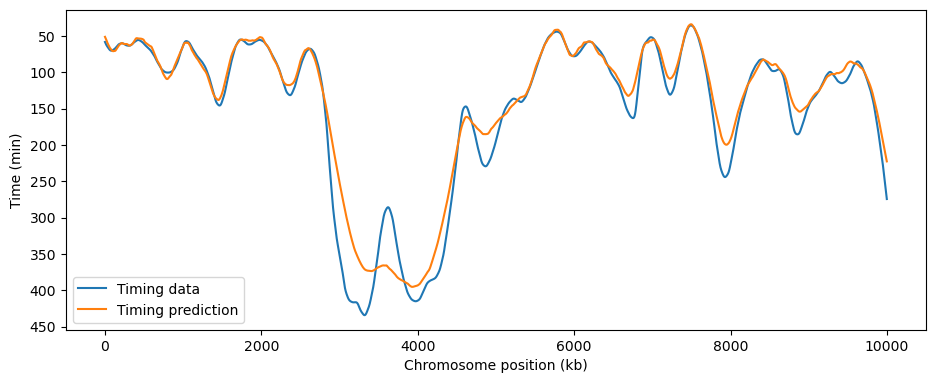

In [54]:
plotf(timedata[10000:20000], timesim[10000:20000],
      labels=['Timing data', 'Timing prediction', 'Timing simulation'], xtitle='Chromosome position (kb)', ytitle='Time (min)', invyQ=True)

In [ ]:
plothm(frep, ylims=(0,150))

In [ ]:
ploth(iod, xtitle='Inter-origin distance (kb)', bin_size=10, xmax=1000)

In [ ]:
plotf(frep, forka, xtitle='Time (min)', labels=['Replicated fraction','Active forks'], dual_axis=True)

In [ ]:
plotf(effic, frates, xtitle='Chromosome position (kb)', labels=['Origin efficiency','Firing rate'], dual_axis=True)

In [ ]:
plotw(nroris, ytitle='Numer of origins', labels=['hESC'], violinQ=True)

In [ ]:
nroris_dict = {}
for chr_number in range(1,23):
    fratesdata = loadcsv('example', example='firing_rate_hESC', chr_number=chr_number)
    simres = rsim(fratesdata, time_statsQ=True, sim_number=100)
    nroris_dict[chr_number] = simres['num_oris']

In [ ]:
plotw(*nroris_dict.values(), xtitle='Chromosome', ytitle='Numer of origins in hESC', labels=[f'{nr}' for nr in range(1,23)], violinQ=True)

### Neater examples

In [ ]:
timedata = loadcsv('example', example='replication_timing_Pl', chr_number=1)
timedata = rescale(timedata, [0, 60])
frates = rfit('replication_timing', 'firing_rate',
              source=timedata, fork_speed=0.6, maxiter=100, resolution=5, perQ=True, stall_rate=0., save_errQ=True)

In [ ]:
simres = rsim(frates, time_statsQ=True, fork_speed=0.6, sim_number=100, perQ=True, stall_rate=0.1)
timesim = simres['replication_timing']

In [ ]:
plotf(timesim, invyQ=True, resolution=5, ylims=(60,-5))

In [ ]:
effic = simres['efficiency']

In [ ]:
mplotf([timesim, [timesim,frates], effic], 
       figsize=(10,2), mregion_high=[range(1,60),range(80,100), range(800,900)], mxtitle='Chromosome position',
       mlabels=[None,['Time','Firing rate'],['Efficiency']], mdual_axis=[False, True,False,False])

In [ ]:
timedata = loadcsv('example', example='replication_timing_hESC', chr_number=1)

In [ ]:
region = range(10000,12000)
mplotf([timedata[region]], mx_array=[[region]], 
       figsize=(10,2), mxtitle='Chromosome position', showgeneQ=True)

In [ ]:
mplotf([timedata[10000:11000]],
       figsize=(10,2), mxtitle='Chromosome position', showgeneQ=False)

In [ ]:
simres = rsim(frates, time_statsQ=True, sim_number=1)

In [ ]:
timesim = simres['replication_timing']
iod = simres['inter_ori_distances']
frep = simres['fraction_replicated']
forka = simres['active_forks']
nroris = simres['num_oris']
effic = simres['efficiency']
rfd = simres['fork_directionality']

In [ ]:
simres.keys()

In [ ]:
region = range(10000,15001)
mplotf([timesim[region], rfd[region]], minvyQ=[True], mx_array=[[region], [region]])

In [ ]:
simres = rsim(frates, time_statsQ=True, sim_number=10)

In [ ]:
sduration = simres['s_phase_duration']
sduration

In [ ]:
len(frates)/(2*1.4)

In [ ]:
math.sqrt(1/(min(frates)*1.4))

In [ ]:
eps = 0.00001
len(frates)/(4* 1.4)+1/(min(frates)*len(frates))*np.log(1/eps)

In [ ]:
min(frates)

### ecDNA tests ###

In [ ]:
fork_speed = 1.4
L = 600
periodicQ = False
period = 200     
x = np.arange(L)

timedata = [250 for i in range(L)]
timedata = 25 * (1 + np.sin(2 * np.pi * x / period))

frates = rfit('replication_timing', 'firing_rate',
              source=timedata, fork_speed=fork_speed, maxiter=100, fit_step=2, perQ=periodicQ)

In [ ]:
timepred = rfit('firing_rate', 'replication_timing', source=frates, perQ=periodicQ)
plotf(timedata, timepred)#, ylims=(200,260))

In [ ]:
plotf(frates, logyQ=True)

In [ ]:
simres = rsim(frates, time_statsQ=True, fork_speed=fork_speed, sim_number=100, perQ=periodicQ)
timesim = simres['replication_timing']
plotf(timedata, timepred, timesim)

In [ ]:
plotf(timedata, timepred)

### More examples

In [ ]:
fork_speed = 1.4
L = 600
period = 200     
x = np.arange(L)

timedata = [250 for i in range(L)]
timedata = 20 * (1 + np.sin(2*np.pi*x/period)) + 30

frates = rfit('replication_timing', 'firing_rate',
              source=timedata, fork_speed=fork_speed, maxiter=100, fit_step=2)

In [ ]:
simres = rsim(ori_rate=frates, fork_speed=fork_speeds, sim_number=1000, time_statsQ=True, stall_rate=0.02)
timesim = simres['replication_timing']
frep = simres['replicated_fraction']
rfork = simres['right_moving_fork_density']
lfork = simres['left_moving_fork_density']
ievents = simres['initiation_events']
cevents = simres['coalescence_events']
plotf(timesim)

In [ ]:
plothm(rfork, ylims=(0,100))
plothm(lfork, ylims=(0,100))

In [ ]:
plothm(frep, ylims=(0,150), resolution_hm=3000)

In [ ]:
plothm(rfork, ylims=(0,25), xlims=(500,600), resolution_hm=500)

In [ ]:
plothm(fork_speeds)

In [ ]:
fork_speeds = fork_speed_linear_decay_matrix(600)

In [ ]:
import numpy as np

def fork_speed_linear_decay_matrix(
    n,
    v0=1.4,
    v_end=0.01,
    t_start=0.0,
    t_end=100.0,
    resolution_time=1.0,
):
    """
    Returns fork_speed as a (T, n) matrix:
    - constant across space (columns)
    - linearly decays in time from v0 at t_start to v_end at t_end
    - clamped to v0 before t_start and to v_end after t_end
    """
    if n <= 0:
        raise ValueError("n must be a positive integer.")
    resolution_time = float(resolution_time)
    if not np.isfinite(resolution_time) or resolution_time <= 0:
        raise ValueError("resolution_time must be a finite positive number.")
    t_start = float(t_start)
    t_end = float(t_end)
    if t_end <= t_start:
        raise ValueError("t_end must be > t_start.")
    v0 = float(v0)
    v_end = float(v_end)
    if not np.isfinite(v0) or not np.isfinite(v_end) or v0 <= 0 or v_end <= 0:
        raise ValueError("v0 and v_end must be finite positive numbers.")

    T = int(np.floor(t_end / resolution_time)) + 1  # includes row for time ~ t_end
    times = np.arange(T, dtype=float) * resolution_time

    frac = (times - t_start) / (t_end - t_start)
    frac = np.clip(frac, 0.0, 1.0)

    v_t = v0 + (v_end - v0) * frac  # (T,)
    return np.repeat(v_t[:, None], n, axis=1).astype(float)